In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

from sklearn.utils import resample

mahinay = pd.read_csv("ecommerce_customer_features.csv")

mahinay.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


In [ ]:
mahinay.duplicated().sum()

np.int64(0)

In [ ]:
print("Shape:", mahinay.shape)
print(mahinay.dtypes)

mahinay.describe()
mahinay.isnull().sum()

Shape: (6000, 15)
Customer_ID                     object
account_age_months               int64
avg_order_value                float64
total_orders                     int64
days_since_last_purchase         int64
discount_usage_rate            float64
return_rate                    float64
customer_support_tickets         int64
loyalty_member                  object
browsing_frequency_per_week    float64
cart_abandonment_rate          float64
product_review_score_avg       float64
engagement_score               float64
satisfaction_score             float64
price_sensitivity_index        float64
dtype: object


,0
Customer_ID,0
account_age_months,0
avg_order_value,0
total_orders,0
days_since_last_purchase,0
discount_usage_rate,0
return_rate,0
customer_support_tickets,0
loyalty_member,0
browsing_frequency_per_week,0


In [ ]:
display(mahinay.dtypes)

,0
Customer_ID,object
account_age_months,int64
avg_order_value,float64
total_orders,int64
days_since_last_purchase,int64
discount_usage_rate,float64
return_rate,float64
customer_support_tickets,int64
loyalty_member,object
browsing_frequency_per_week,float64


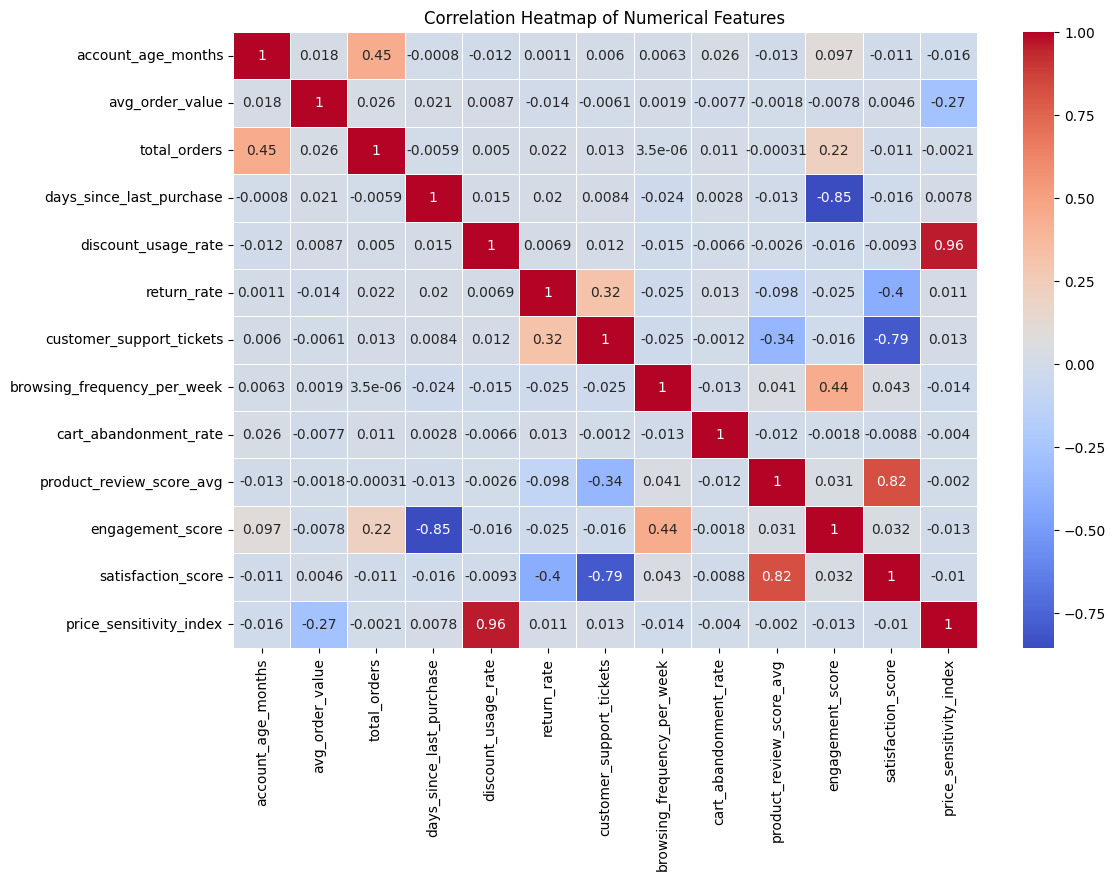

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
correlation_matrix = mahinay.corr(numeric_only=True)

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [ ]:


numerical_cols = mahinay.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = mahinay.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['account_age_months', 'avg_order_value', 'total_orders',
       'days_since_last_purchase', 'discount_usage_rate', 'return_rate',
       'customer_support_tickets', 'browsing_frequency_per_week',
       'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score',
       'satisfaction_score', 'price_sensitivity_index'],
      dtype='object')
Categorical Columns: Index(['Customer_ID', 'loyalty_member'], dtype='object')


In [ ]:
num_imputer = SimpleImputer(strategy='median')

cat_imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore')

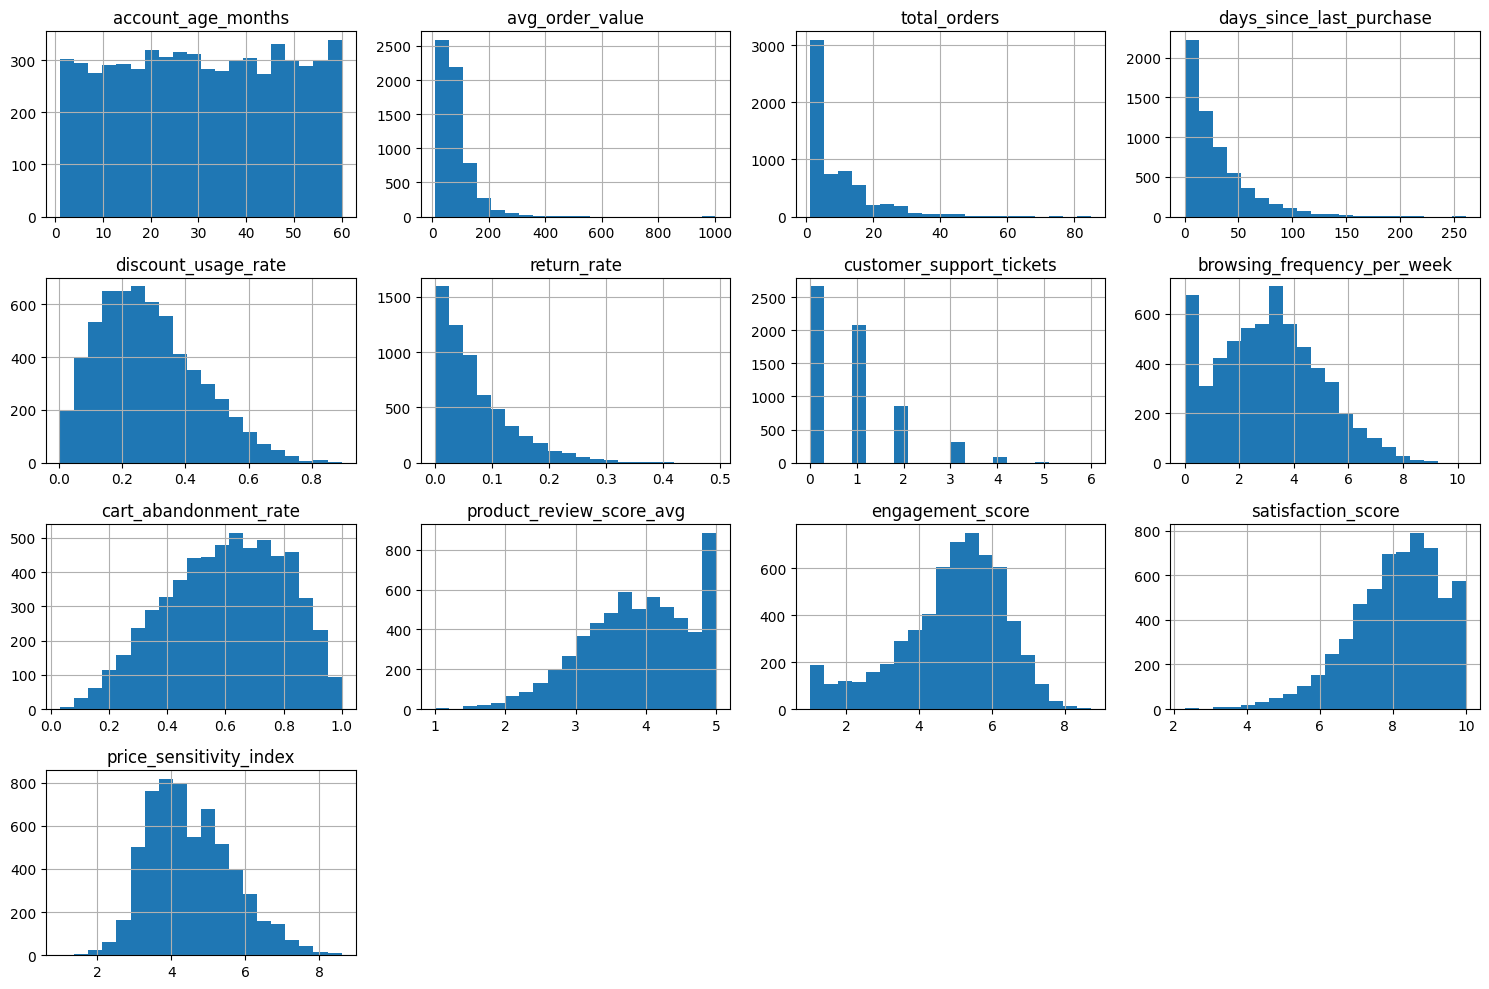

In [ ]:
mahinay.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

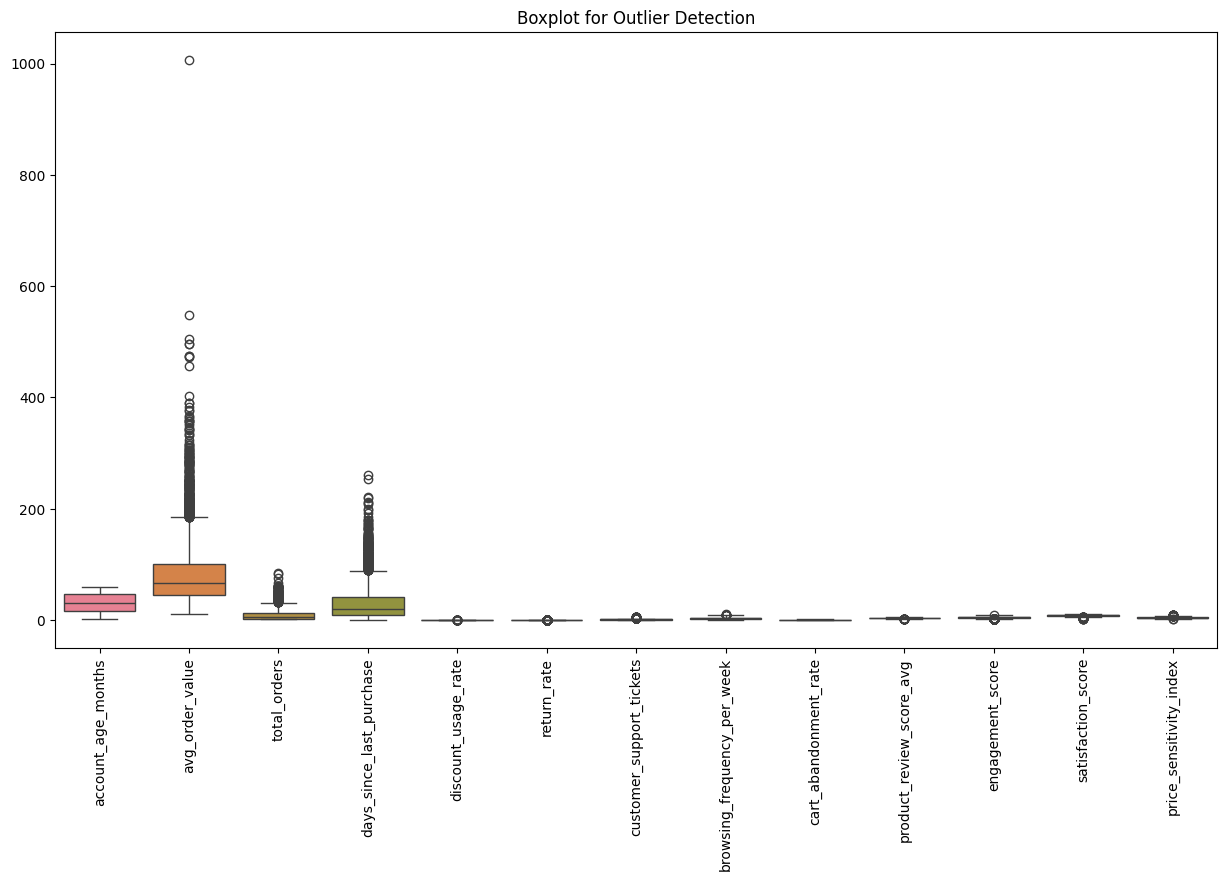

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=mahinay[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

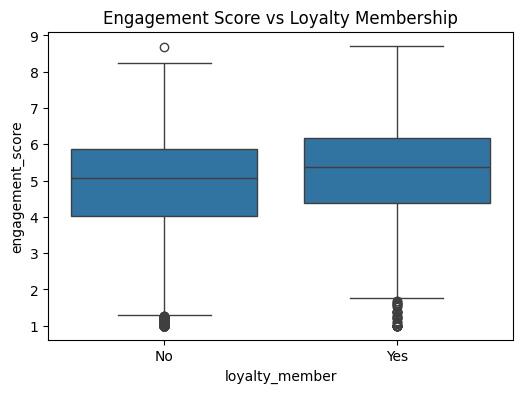

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loyalty_member', y='engagement_score', data=mahinay)
plt.title("Engagement Score vs Loyalty Membership")
plt.show()

In [ ]:
mahinay = mahinay.drop(columns=['Customer_ID'])

In [ ]:
scaler = StandardScaler()

In [ ]:
mahinay['loyalty_member'] = mahinay['loyalty_member'].astype(str).str.lower().map({
    'no': 0,
    'yes': 1
})
X = mahinay.drop(columns=['loyalty_member'])
y = mahinay['loyalty_member']

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

num_pipeline = Pipeline(steps=[
    ('imputer', num_imputer),
    ('scaler', scaler)
])

cat_pipeline = Pipeline(steps=[
    ('imputer', cat_imputer),
    ('encoder', encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ]
)

In [ ]:
# X and y are now defined within the preprocessor setup cell (RSZUDLXERaM9).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)

Processed Training Shape: (4800, 13)


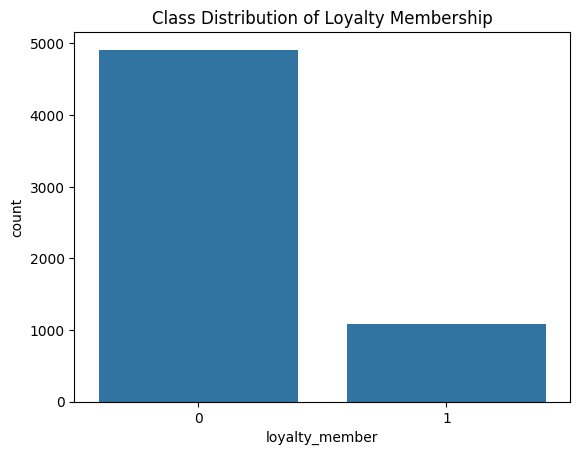

loyalty_member
0    4915
1    1085
Name: count, dtype: int64


In [ ]:
sns.countplot(x='loyalty_member', data=mahinay)
plt.title("Class Distribution of Loyalty Membership")
plt.show()

print(mahinay['loyalty_member'].value_counts())

In [ ]:
print(y_train.value_counts())

loyalty_member
0    3932
1     868
Name: count, dtype: int64


In [ ]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

After SMOTE:
loyalty_member
0    3932
1    3932
Name: count, dtype: int64


/tmp/ipykernel_235/480321732.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loyalty_member', data=mahinay, palette='viridis')
/tmp/ipykernel_235/480321732.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_balanced, palette='viridis')


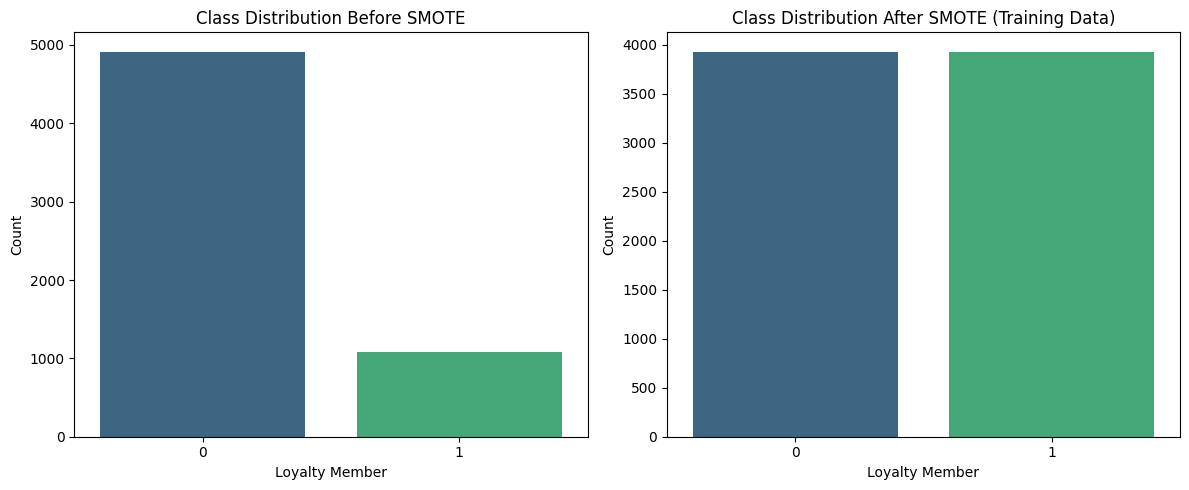

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='loyalty_member', data=mahinay, palette='viridis')
plt.title('Class Distribution Before SMOTE')
plt.xlabel('Loyalty Member')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_balanced, palette='viridis')
plt.title('Class Distribution After SMOTE (Training Data)')
plt.xlabel('Loyalty Member')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
def remove_outliers_iqr(data, columns):
    mahinay_clean = data.copy()
    for col in columns:
        Q1 = mahinay_clean[col].quantile(0.25)
        Q3 = mahinay_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mahinay_clean = mahinay_clean[(mahinay_clean[col] >= lower) & (mahinay_clean[col] <= upper)]

    return mahinay_clean

# **Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

log_model = LogisticRegression(max_iter=1000)

X_train_final = X_train_balanced
y_train_final = y_train_balanced

log_model.fit(X_train_final, y_train_final)

y_pred_log = log_model.predict(X_test_processed)
y_prob_log = log_model.predict_proba(X_test_processed)[:,1]

In [ ]:
print("=== Logistic Regression Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

=== Logistic Regression Results ===
Accuracy: 0.6991666666666667
Precision: 0.31443298969072164
Recall: 0.5622119815668203
F1 Score: 0.4033057851239669
ROC AUC: 0.6756801102615431

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.73      0.80       983
           1       0.31      0.56      0.40       217

    accuracy                           0.70      1200
   macro avg       0.60      0.65      0.60      1200
weighted avg       0.78      0.70      0.73      1200



In [ ]:
import pandas as pd

metrics_log = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_prob_log)
    ]
})

display(metrics_log)

,Metric,Value
0,Accuracy,0.699167
1,Precision,0.314433
2,Recall,0.562212
3,F1 Score,0.403306
4,ROC AUC,0.675680


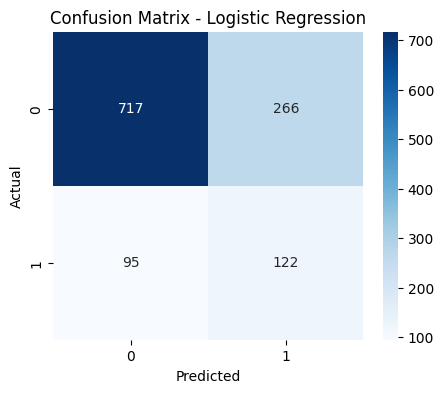

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **MY MODEL - Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train_final, y_train_final)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:,1]

In [ ]:
print("=== Random Forest Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.7891666666666667
Precision: 0.3767123287671233
Recall: 0.2534562211981567
F1 Score: 0.30303030303030304
ROC AUC: 0.6243466112858689

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       983
           1       0.38      0.25      0.30       217

    accuracy                           0.79      1200
   macro avg       0.61      0.58      0.59      1200
weighted avg       0.76      0.79      0.77      1200



In [ ]:
import pandas as pd

metrics_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(metrics_rf)

,Metric,Value
0,Accuracy,0.789167
1,Precision,0.376712
2,Recall,0.253456
3,F1 Score,0.303030
4,ROC AUC,0.624347


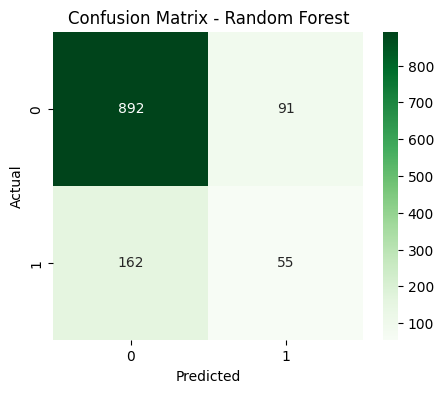

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

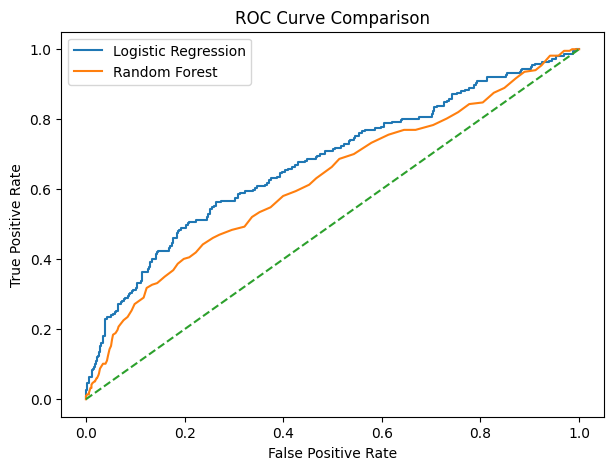

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.699167,0.314433,0.562212,0.403306,0.675680
1,Random Forest,0.789167,0.376712,0.253456,0.303030,0.624347


In [ ]:
display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.699167,0.314433,0.562212,0.403306,0.675680
1,Random Forest,0.789167,0.376712,0.253456,0.303030,0.624347


# **Hyper Parameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_model_tune = LogisticRegression(max_iter=5000)

param_grid_log = {
    'C': [0.001, 0.01, 0.1],
    'penalty': ['l1', 'l2','elasticnet'],
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced'],
    'l1_ratio': [0.2, 0.5, 0.8]
}

grid_log = GridSearchCV(
    log_model_tune,
    param_grid_log,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=2
)

grid_log.fit(X_train_final, y_train_final)

print("Best Parameters:", grid_log.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'C': 0.001, 'class_weight': None, 'l1_ratio': 0.2, 'penalty': 'l1', 'solver': 'liblinear'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

In [ ]:
best_log = grid_log.best_estimator_

y_pred_log_tune = best_log.predict(X_test_processed)
y_prob_log_tune = best_log.predict_proba(X_test_processed)[:,1]

In [ ]:
print("=== Logistic Regression Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_log_tune))
print("Precision:", precision_score(y_test, y_pred_log_tune))
print("Recall:", recall_score(y_test, y_pred_log_tune))
print("F1 Score:", f1_score(y_test, y_pred_log_tune))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log_tune))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log_tune))

=== Logistic Regression Results ===
Accuracy: 0.655
Precision: 0.28817204301075267
Recall: 0.6175115207373272
F1 Score: 0.39296187683284456
ROC AUC: 0.6778084580729545

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.66      0.76       983
           1       0.29      0.62      0.39       217

    accuracy                           0.66      1200
   macro avg       0.59      0.64      0.58      1200
weighted avg       0.78      0.66      0.69      1200



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier

rf_model_tune = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': ['5', None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}
scorer = make_scorer(f1_score)

grid_rf = GridSearchCV(
    estimator=rf_model_tune,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_final, y_train_final)

print("Best Parameters:", grid_rf.best_params_)
print("Best F1 Score for Random Forest:", grid_rf.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 12.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_pa

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score for Random Forest: 0.8674319123011275


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf_tune = best_rf.predict(X_test_processed)
y_prob_rf_tune = best_rf.predict_proba(X_test_processed)[:,1]

In [ ]:
print("=== Random Forest Results ===")

print("Accuracy:", accuracy_score(y_test, y_pred_rf_tune))
print("Precision:", precision_score(y_test, y_pred_rf_tune))
print("Recall:", recall_score(y_test, y_pred_rf_tune))
print("F1 Score:", f1_score(y_test, y_pred_rf_tune))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf_tune))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_tune))

=== Random Forest Results ===
Accuracy: 0.7883333333333333
Precision: 0.3669064748201439
Recall: 0.2350230414746544
F1 Score: 0.28651685393258425
ROC AUC: 0.6254951690255073

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       983
           1       0.37      0.24      0.29       217

    accuracy                           0.79      1200
   macro avg       0.61      0.57      0.58      1200
weighted avg       0.76      0.79      0.77      1200



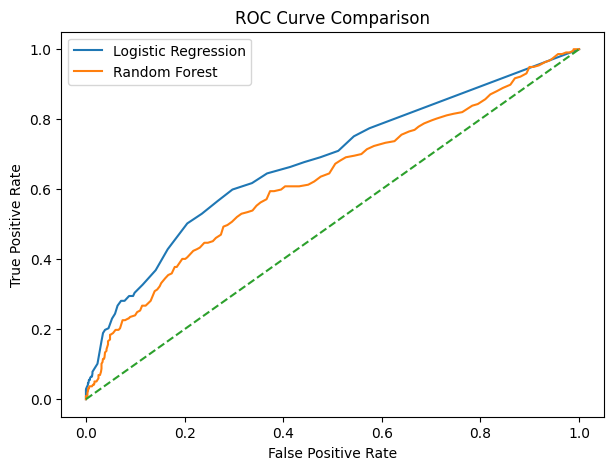

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_tune)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tune)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import joblib

model_bundle = {
    'logistic_regression_model': log_model_tune,
    'random_forest_model': best_rf,
    'preprocessor': preprocessor,
    'feature_columns': list(X.columns)
}

joblib.dump(model_bundle, 'customer_loyalty_model_bundle_v2.pkl')
print("Model bundle saved as 'customer_loyalty_model_bundle_v2.pkl'")

Model bundle saved as 'customer_loyalty_model_bundle_v2.pkl'
